# Real-world Data Wrangling

In [1]:
#Imports libraries that will be used
import pandas as pd
import numpy as np
import requests
import plotly.express as px

## 1. Gather data

### **1.1.** Problem Statement
I want to see if the relation betwen hospitalization rate and covid deaths changes between genders.

### **1.2.** Gather at least two datasets using two different data gathering methods

#### **Dataset 1**

Type: CSV File

Method: The data was gathered using the "Manually Downloading files" method from [Data.gov](https://catalog.data.gov/dataset/provisional-covid-19-death-counts-rates-and-percent-of-total-deaths-by-jurisdiction-of-res)

Dataset variables I will be looking at: 

* Year: The year the observation took place
* Month: The month the observation took place
* State: The state the observation took place in
* COVID-19 Deaths: The number of Covid deaths in the observation

In [2]:
# Loads the data from local data store
covid_deaths = pd.read_csv(
    'Provisional_COVID-19_Death_Counts_by_Week_Ending_Date_and_State.csv')

#### Dataset 2

Type: CSV File

Method: The data was gathered using the "Programmatically Downloading files" method from Data.gov.

Dataset variables:

* State: The state the observation took place in
* YearMonth: The year and month the observation took place in
* Sex_label: The gender of individuals in the observation
* MonthlyRate: The rate of covid hospitalizations in the observation

In [3]:
# Sets url to a link of the data
url = 'https://data.cdc.gov/api/views/cf5u-bm9w/rows.csv?accessType=DOWNLOAD'
# Downloads the data from the link and puts it into a dataframe
covid_hospital = pd.read_csv(url)

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [4]:
# Stores the raw data in the local data store
covid_hospital.to_csv('covid_hospital.csv', index=False, encoding="utf-8")

## 2. Assess data

### Quality Issue 1:

In [5]:
# Inspects the first 5 rows of the covid_deaths dataframe
covid_deaths.head(5)

,Data as of,Start Date,End Date,Group,Year,Month,MMWR Week,Week Ending Date,State,COVID-19 Deaths,Total Deaths,Percent of Expected Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",Footnote
0,07/03/2025,12/29/2019,01/04/2020,By Week,2019/2020,NaN,1.0,01/04/2020,United States,0.0,60170.0,98.0,4111.0,0.0,434.0,4545.0,NaN
1,07/03/2025,01/05/2020,01/11/2020,By Week,2020,NaN,2.0,01/11/2020,United States,1.0,60734.0,97.0,4153.0,1.0,475.0,4628.0,NaN
2,07/03/2025,01/12/2020,01/18/2020,By Week,2020,NaN,3.0,01/18/2020,United States,2.0,59362.0,98.0,4066.0,2.0,468.0,4534.0,NaN
3,07/03/2025,01/19/2020,01/25/2020,By Week,2020,NaN,4.0,01/25/2020,United States,3.0,59162.0,99.0,3915.0,0.0,500.0,4418.0,NaN
4,07/03/2025,01/26/2020,02/01/2020,By Week,2020,NaN,5.0,02/01/2020,United States,0.0,58834.0,99.0,3818.0,0.0,481.0,4299.0,NaN


In [6]:
# Inspects the non-null count and datatypes of the covid_deaths dataframe
covid_deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19440 entries, 0 to 19439
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Data as of                                19440 non-null  object 
 1   Start Date                                19440 non-null  object 
 2   End Date                                  19440 non-null  object 
 3   Group                                     19440 non-null  object 
 4   Year                                      19386 non-null  object 
 5   Month                                     3564 non-null   float64
 6   MMWR Week                                 15498 non-null  float64
 7   Week Ending Date                          15498 non-null  object 
 8   State                                     19440 non-null  object 
 9   COVID-19 Deaths                           15249 non-null  float64
 10  Total Deaths                      

Issue and justification: The month column should be an object datatype as the year column is as well and month does not need to be a float datatype.

### Quality Issue 2:

In [7]:
# Inspects the first 5 rows of the covid_deaths dataframe
covid_deaths.head(10)

,Data as of,Start Date,End Date,Group,Year,Month,MMWR Week,Week Ending Date,State,COVID-19 Deaths,Total Deaths,Percent of Expected Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",Footnote
0,07/03/2025,12/29/2019,01/04/2020,By Week,2019/2020,NaN,1.0,01/04/2020,United States,0.0,60170.0,98.0,4111.0,0.0,434.0,4545.0,NaN
1,07/03/2025,01/05/2020,01/11/2020,By Week,2020,NaN,2.0,01/11/2020,United States,1.0,60734.0,97.0,4153.0,1.0,475.0,4628.0,NaN
2,07/03/2025,01/12/2020,01/18/2020,By Week,2020,NaN,3.0,01/18/2020,United States,2.0,59362.0,98.0,4066.0,2.0,468.0,4534.0,NaN
3,07/03/2025,01/19/2020,01/25/2020,By Week,2020,NaN,4.0,01/25/2020,United States,3.0,59162.0,99.0,3915.0,0.0,500.0,4418.0,NaN
4,07/03/2025,01/26/2020,02/01/2020,By Week,2020,NaN,5.0,02/01/2020,United States,0.0,58834.0,99.0,3818.0,0.0,481.0,4299.0,NaN
5,07/03/2025,02/02/2020,02/08/2020,By Week,2020,NaN,6.0,02/08/2020,United States,4.0,59482.0,100.0,3823.0,1.0,520.0,4346.0,NaN
6,07/03/2025,02/09/2020,02/15/2020,By Week,2020,NaN,7.0,02/15/2020,United States,6.0,58815.0,100.0,3848.0,1.0,561.0,4413.0,NaN
7,07/03/2025,02/16/2020,02/22/2020,By Week,2020,NaN,8.0,02/22/2020,United States,6.0,58912.0,101.0,3719.0,3.0,566.0,4288.0,NaN
8,07/03/2025,02/23/2020,02/29/2020,By Week,2020,NaN,9.0,02/29/2020,United States,9.0,59334.0,103.0,3842.0,5.0,657.0,4503.0,NaN
9,07/03/2025,03/01/2020,03/07/2020,By Week,2020,NaN,10.0,03/07/2020,United States,38.0,59694.0,103.0,3977.0,19.0,635.0,4630.0,NaN


In [8]:
# Inspects the non-null count and datatypes of the covid_deaths dataframe
covid_deaths.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19440 entries, 0 to 19439
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Data as of                                19440 non-null  object 
 1   Start Date                                19440 non-null  object 
 2   End Date                                  19440 non-null  object 
 3   Group                                     19440 non-null  object 
 4   Year                                      19386 non-null  object 
 5   Month                                     3564 non-null   float64
 6   MMWR Week                                 15498 non-null  float64
 7   Week Ending Date                          15498 non-null  object 
 8   State                                     19440 non-null  object 
 9   COVID-19 Deaths                           15249 non-null  float64
 10  Total Deaths                      

Issue and justification: COVID-19 Deaths should have a different column name and the datatype should be int to make it slightly easier to work with.

### Tidiness Issue 1:

In [9]:
# Inspects the first 5 rows of the covid_hospital dataframe
covid_hospital.head(5)

,State,Season,_YearMonth,AgeCategory_Legend,Sex_Label,Race_Label,MonthlyRate,Type
0,Utah,2021-22,202206.0,All,All,All,36.0,Crude Rate
1,Utah,2021-22,202202.0,All,All,All,40.4,Crude Rate
2,Utah,2021-22,202203.0,All,All,All,12.1,Crude Rate
3,Utah,2021-22,202112.0,All,All,All,38.9,Crude Rate
4,Utah,2021-22,202207.0,All,All,All,34.5,Crude Rate


In [10]:
# Inspects the non-null count and datatypes of the covid_deaths dataframe
covid_hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41792 entries, 0 to 41791
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               41792 non-null  object 
 1   Season              41792 non-null  object 
 2   _YearMonth          41792 non-null  float64
 3   AgeCategory_Legend  41792 non-null  object 
 4   Sex_Label           41792 non-null  object 
 5   Race_Label          41792 non-null  object 
 6   MonthlyRate         40887 non-null  float64
 7   Type                41792 non-null  object 
dtypes: float64(2), object(6)
memory usage: 2.6+ MB


Issue and justification: _YearMonth column should be split into a year and month column as it contains two observations in one cell

### Tidiness Issue 2: 

In [11]:
# Inspects the first 5 rows of the covid_hospital dataframe
covid_hospital.head(5)

,State,Season,_YearMonth,AgeCategory_Legend,Sex_Label,Race_Label,MonthlyRate,Type
0,Utah,2021-22,202206.0,All,All,All,36.0,Crude Rate
1,Utah,2021-22,202202.0,All,All,All,40.4,Crude Rate
2,Utah,2021-22,202203.0,All,All,All,12.1,Crude Rate
3,Utah,2021-22,202112.0,All,All,All,38.9,Crude Rate
4,Utah,2021-22,202207.0,All,All,All,34.5,Crude Rate


In [12]:
# Inspects the unique number of values in each column for dataframe covid_hospital
covid_hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41792 entries, 0 to 41791
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               41792 non-null  object 
 1   Season              41792 non-null  object 
 2   _YearMonth          41792 non-null  float64
 3   AgeCategory_Legend  41792 non-null  object 
 4   Sex_Label           41792 non-null  object 
 5   Race_Label          41792 non-null  object 
 6   MonthlyRate         40887 non-null  float64
 7   Type                41792 non-null  object 
dtypes: float64(2), object(6)
memory usage: 2.6+ MB


Issue and justification: The Season column should be converted into two different columns, Start Year and End Year as it contains two different datapoints

## 3. Clean data

In [13]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted
covidHospital = covid_hospital.copy()
covidDeaths = covid_deaths.copy()

### **Quality Issue 1: Month Datatype Fix**

In [14]:
# Converts the Month datatype to object by stripping the decimal points while preserving the np.nan
covidDeaths['Month'] = np.where(pd.isnull(covidDeaths['Month']), np.nan, covidDeaths['Month'].apply(lambda x: f'{x:.0f}'))

In [68]:
# Validates the cleaning was successful by checking datatype of month column
if covidDeaths['Month'].dtype == object:
    print('Month Datatype is object')

Month Datatype is object


Justification: The Month column will be used later to merge the datasets so ensuring both month columns share the same datatype is crucial.

### **Quality Issue 2: COVID-19 Deaths Column Name and Datatype**

In [16]:
# Changes the datatype of the COVID-19 Deaths column to 'Int64' and creates a new column for this new data as COVID-19_Deaths
covidDeaths['COVID-19_Deaths'] = covidDeaths['COVID-19 Deaths'].astype('Int64')

In [70]:
# Checks the datatypes of the dataframe
if covidDeaths['COVID-19_Deaths'].dtype == 'Int64':
    print('COVID-19_Deaths Datatype is Int64')

COVID-19_Deaths Datatype is Int64


Justification: Changing the column name to COVID-19_Deaths makes it easier to use the column and helps keep the column names consistent and changing the datatype also does the same thing as it does not need to be a float (as you cannot have a part of a death) so it makes it easier to look at.

### **Tidiness Issue 1: Splitting _YearMonth into Two Columns**

In [18]:
# Converts the _YearMonth column to a string datatype
covidHospital['_YearMonth'] = np.where(pd.isnull(covidHospital['_YearMonth']), np.nan, covidHospital['_YearMonth'].apply(lambda x: f'{x:.0f}'))

In [19]:
# Splits the _YearMonth column into two columns Year and Month based on the first 4 str characters and the remaining
covidHospital['Year'] = covidHospital['_YearMonth'].str[:4]
covidHospital['Month'] = covidHospital['_YearMonth'].str[4:]

In [20]:
# Strips the 0 from infront of the months that are only 1 digit
covidHospital['Month'] = covidHospital['Month'].str.lstrip('0')

In [21]:
# Checks to see if the Year and Month column visually look correct
covidHospital.head(5)

,State,Season,_YearMonth,AgeCategory_Legend,Sex_Label,Race_Label,MonthlyRate,Type,Year,Month
0,Utah,2021-22,202206,All,All,All,36.0,Crude Rate,2022,6
1,Utah,2021-22,202202,All,All,All,40.4,Crude Rate,2022,2
2,Utah,2021-22,202203,All,All,All,12.1,Crude Rate,2022,3
3,Utah,2021-22,202112,All,All,All,38.9,Crude Rate,2021,12
4,Utah,2021-22,202207,All,All,All,34.5,Crude Rate,2022,7


In [71]:
# Ensures the datatype of year column is correct
if covidHospital['Year'].dtype == object:
    print('Year Datatype is object')

Year Datatype is object


In [73]:
# Ensures the datatype of month column is correct
if covidHospital['Month'].dtype == object:
    print('Month Datatype is object')

Month Datatype is object


Justification: Splitting Year and Month into two columns will make it easier to merge the two dataframes and it will potentially allow analysis to be performed on a month to month basis

### **Tidiness Issue 2: Splitting Season Into Two Columns**

In [23]:
# Takes the first four characters in the Season column and makes a new column Start_Year
covidHospital['Start_Year'] = covidHospital['Season'].str[:4]

In [24]:
# Creates End_Year by taking the first two digits of the string and the last two digits and combines them
covidHospital['Endleft_year'] = covidHospital['Season'].str[:2]
covidHospital['Endright_year'] = covidHospital['Season'].str[5:]
covidHospital['End_Year'] = covidHospital['Endleft_year'] + covidHospital['Endright_year']

In [25]:
# Drops the left and right year columns as they were placeholders to make the End_Year column
covidHospital = covidHospital.drop(['Endleft_year', 'Endright_year'], axis=1)

In [26]:
# Checks if the columns were made properly
covidHospital.head(5)

,State,Season,_YearMonth,AgeCategory_Legend,Sex_Label,Race_Label,MonthlyRate,Type,Year,Month,Start_Year,End_Year
0,Utah,2021-22,202206,All,All,All,36.0,Crude Rate,2022,6,2021,2022
1,Utah,2021-22,202202,All,All,All,40.4,Crude Rate,2022,2,2021,2022
2,Utah,2021-22,202203,All,All,All,12.1,Crude Rate,2022,3,2021,2022
3,Utah,2021-22,202112,All,All,All,38.9,Crude Rate,2021,12,2021,2022
4,Utah,2021-22,202207,All,All,All,34.5,Crude Rate,2022,7,2021,2022


Justification: Splitting the Season column into two different solves the issue of two observations in one column, and it also helps if later down the line someone wants to sort by start or end year, or filter by them.

### Additional Cleaning

In [27]:
# Creates new columns for each value in Sex_label and adds a prefix to the column names
sex_dummies = pd.get_dummies(covidHospital['Sex_Label'], prefix='Gender')

In [28]:
# Adds the columns to the dataframe
covidHospital = pd.concat([covidHospital, sex_dummies], axis = 1)

In [29]:
# Checcks if the new columns are created
covidHospital.head(5)

,State,Season,_YearMonth,AgeCategory_Legend,Sex_Label,Race_Label,MonthlyRate,Type,Year,Month,Start_Year,End_Year,Gender_All,Gender_Female,Gender_Male
0,Utah,2021-22,202206,All,All,All,36.0,Crude Rate,2022,6,2021,2022,True,False,False
1,Utah,2021-22,202202,All,All,All,40.4,Crude Rate,2022,2,2021,2022,True,False,False
2,Utah,2021-22,202203,All,All,All,12.1,Crude Rate,2022,3,2021,2022,True,False,False
3,Utah,2021-22,202112,All,All,All,38.9,Crude Rate,2021,12,2021,2022,True,False,False
4,Utah,2021-22,202207,All,All,All,34.5,Crude Rate,2022,7,2021,2022,True,False,False


### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [30]:
# Removes the unnecessary columns from both dataframes
covidDeaths_clean = covidDeaths.drop(columns=['Data as of','COVID-19 Deaths','Start Date', 'End Date', 'Group','MMWR Week', 'Week Ending Date','Total Deaths', 'Percent of Expected Deaths',
                                              'Pneumonia Deaths','Pneumonia and COVID-19 Deaths','Influenza Deaths','Pneumonia, Influenza, or COVID-19 Deaths','Footnote',])
covidHospital_clean = covidHospital.drop(columns=['Season','_YearMonth','AgeCategory_Legend','Race_Label','Type'])

In [31]:
# Merges the dataframes
covid_DeathsAndHospital = pd.merge(covidDeaths_clean,covidHospital_clean,on=['State','Year','Month'], how='right')

In [32]:
# Ensures we only have the columns we want
covid_DeathsAndHospital.head(5)

,Year,Month,State,COVID-19_Deaths,Sex_Label,MonthlyRate,Start_Year,End_Year,Gender_All,Gender_Female,Gender_Male
0,2022,6,Utah,69,All,36.0,2021,2022,True,False,False
1,2022,2,Utah,294,All,40.4,2021,2022,True,False,False
2,2022,3,Utah,98,All,12.1,2021,2022,True,False,False
3,2021,12,Utah,291,All,38.9,2021,2022,True,False,False
4,2022,7,Utah,92,All,34.5,2021,2022,True,False,False


## 4. Update your data store

In [33]:
# Saves the cleaned and merged dataframe locally
covid_DeathsAndHospital.to_csv('covid_DeathsAndHospital.csv', index=False, encoding="utf-8")

## 5. Answer the research question

### **5.1:** Define and answer the research question

*Research question:* I want to see if the relation betwen hospitalization rate and covid deaths changes between genders.

### Original Visualizations

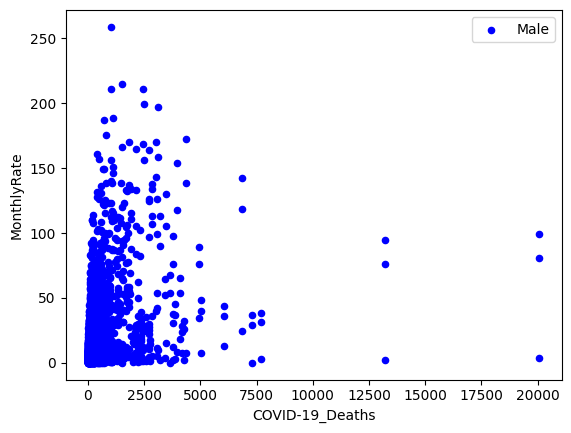

In [34]:
# Plots the first visualization
ax = covid_DeathsAndHospital.query('Gender_Male == True').plot.scatter(x='COVID-19_Deaths', y='MonthlyRate', color='blue', label='Male')

This visual shows us the hospitalization rate to Covid deaths for males

<Axes: xlabel='COVID-19_Deaths', ylabel='MonthlyRate'>

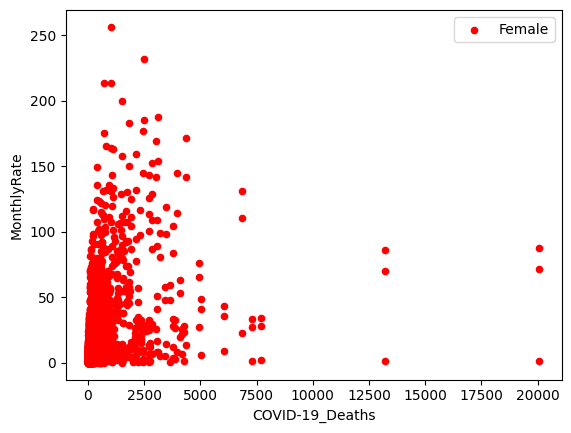

In [35]:
# Plots the second visualization
covid_DeathsAndHospital.query('Gender_Female == True').plot.scatter(x='COVID-19_Deaths', y='MonthlyRate', color='red', label='Female')

This visual shows us the hospitalization rate to Covid deaths for females

### New Visualizations Using Plotly

In [54]:
# Creates a new dataframe for use in the first visulization
covid_DeathsAndHospital_Male = covid_DeathsAndHospital.query('Gender_Male == True')

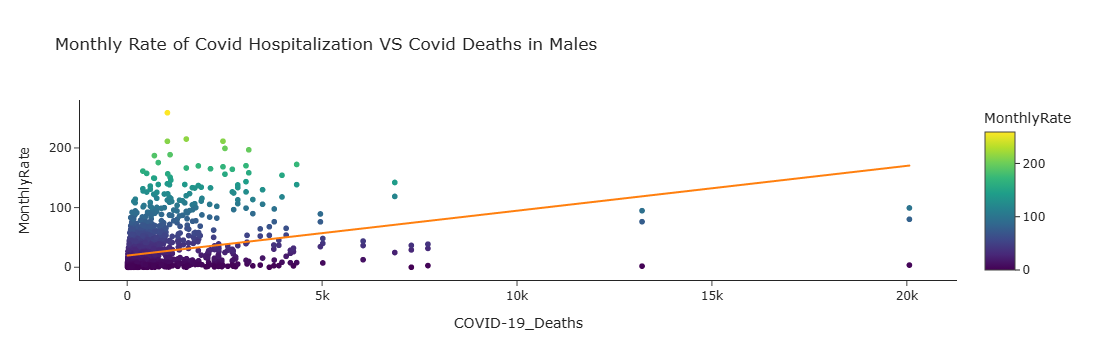

In [55]:
# Creates visualization using plotly
fig = px.scatter(covid_DeathsAndHospital_Male, 
                 x='COVID-19_Deaths', 
                 y='MonthlyRate', 
                 trendline='ols', 
                 color='MonthlyRate',
                 template='simple_white',
                 title = 'Monthly Rate of Covid Hospitalization VS Covid Deaths in Males'
                )
fig.show()

In [56]:
# Creates a new dataframe for use in the second visulization
covid_DeathsAndHospital_Female = covid_DeathsAndHospital.query('Gender_Female == True')

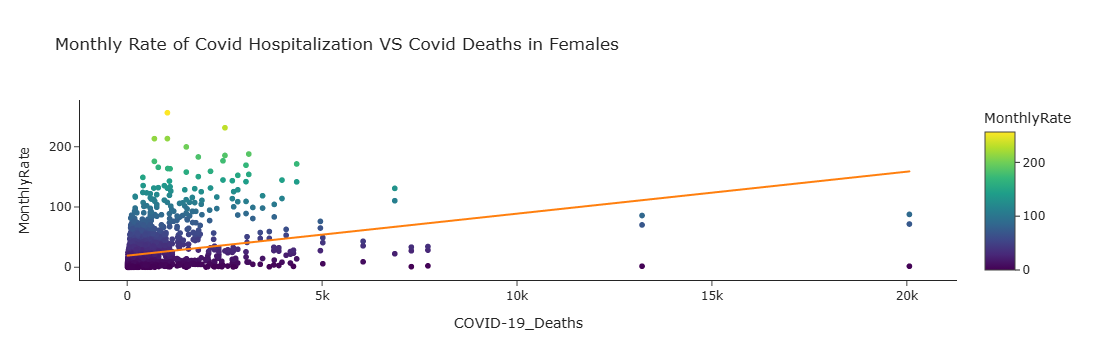

In [57]:
# Creates visualization using plotly
fig = px.scatter(covid_DeathsAndHospital_Female, 
                 x='COVID-19_Deaths', 
                 y='MonthlyRate', 
                 trendline='ols', 
                 color='MonthlyRate',
                 template='simple_white',
                 title = 'Monthly Rate of Covid Hospitalization VS Covid Deaths in Females'
                )
fig.show()

*Answer to research question:* There is not a **significant** difference between male and female; however, male is slightly less clusted at around the (174,2500) position which shows that men were slightly more likely to survive their hospitalizations, otherwise they look very similar.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* If I had more time to complete this project, I would look into other labels mentioned in the covid hospitalizations dataset. Some of these columns would need slight work to fix their data quality and structure as they are (mostly) categorical data. As they are categorical data points, they could undergo the same structure change that I did with Sex_label to make a male and female column. I would see if there were any categorical datapoints that significantly increased or decreased the monthly rate of hospitalizations or the number of deaths.

# Sources

The covid deaths dataset was found at [Data.gov](https://catalog.data.gov/dataset/provisional-covid-19-death-counts-by-week-ending-date-and-state)

The hospitalization rate dataset was found at [Data.gov](https://catalog.data.gov/dataset/provisional-covid-19-death-counts-rates-and-percent-of-total-deaths-by-jurisdiction-of-res)